In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scripts.notebooks.lamDahlquist import lam

In [2]:
# Dahlquist test problem parameters
alpha = 6.001   # to avoid resonance regime
u0 = 1+0j
t0 = 0
pStart = 1

In [3]:
# analytical solver
def analytical_one_step(u0, t0, t1, lam):
    C = np.exp(-lam*t0)*(u0 + (alpha*np.cos(alpha*t0) + lam*np.sin(alpha*t0))/(alpha**2 + lam**2))
    u = C*np.exp(lam*t1) - (alpha*np.cos(alpha*t1) + lam*np.sin(alpha*t1))/(alpha**2 + lam**2)
    return u

def analyticalDahlquist(u0, t0, t1, dt, pStart):
    tt = np.linspace(t0, t1, int((t1-t0)/dt)+1)
    u = np.zeros_like(tt, dtype=complex)    
    N = pStart
    occ = 0
    TP = []
    UP = []
    u[0] = u0
    for i in range(1, len(tt)):
        lam_nP = lam(N)
        assert lam_nP**2 + alpha**2 != 0, "resonance regime, different analytical solution"
        u[i] = analytical_one_step(u[i-1], tt[i-1], tt[i], lam_nP)
        occ += u[i].imag*u[i-1].imag <0 # check for sign change in the imaginary part
        if occ == 2: # check for sign change in the imaginary part
            tP = np.interp(0, [u[i-1].imag, u[i].imag], [tt[i-1], tt[i]])
            uP_real = np.interp(tP, [tt[i-1], tt[i]], [u[i-1], u[i]])
            UP.append(uP_real + 0j)
            TP.append(tP) 
            N += 1
            occ = 0
    return tt, u, np.asarray(TP), np.asarray(UP)


In [4]:
# numerical solver
def timeOneStep(u0, t1, dt, lam):
    u = (u0 + dt*np.sin(alpha*t1))/(1-dt*lam)
    return u
def timeStepperDahlquist(u0, t0, t1, dt, pStart,occ=0):  
    tt = np.linspace(t0, t1, int((t1-t0)/dt)+1)
    u = np.zeros_like(tt, dtype=complex)
    u[0] = u0
    N = pStart
    TP = []
    UP = []
    for i in range(1,len(tt)):
        lam_Np = lam(N)
        assert lam_Np**2 + alpha**2 != 0, "resonance regime, different analytical solution"
        u[i] = timeOneStep(u[i-1], tt[i], dt, lam_Np)
        occ += u[i].imag*u[i-1].imag < 0 # check for sign change in the imaginary part
        if occ == 2: # we completed a full period
            tp = np.interp(0, [u[i-1].imag, u[i].imag], [tt[i-1], tt[i]])
            up_real = np.interp(tp, [tt[i-1], tt[i]], [u[i-1], u[i]])
            UP.append(up_real + 0j)
            TP.append(tp) 
            N += 1
            occ = 0
    return tt, u, np.asarray(TP), np.asarray(UP), occ, N


In [5]:
tEnd = 15
dt = 0.001

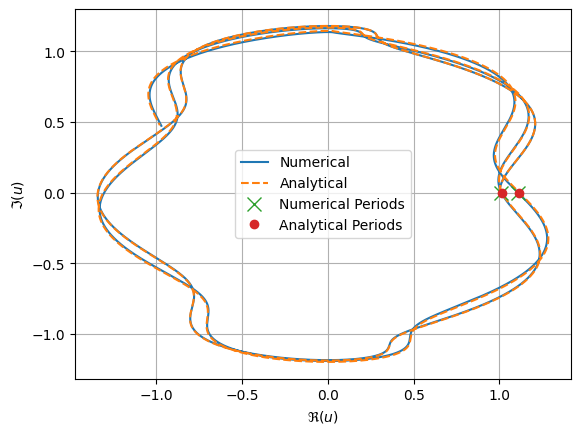

In [6]:
tNum1, uNum1, TPNum1, UPNum1, occNum1, NNum1 = timeStepperDahlquist(u0, t0, tEnd, dt, pStart ,0)
tTh, uTh, TPTh, UPTh = analyticalDahlquist(u0, t0, tEnd, dt, pStart)

plt.plot(uNum1.real, uNum1.imag, label="Numerical")
plt.plot(uTh.real, uTh.imag, "--", label="Analytical")
plt.plot(UPNum1.real, UPNum1.imag, "x", label="Numerical Periods", markersize=10)
plt.plot(UPTh.real, UPTh.imag, "o", label="Analytical Periods")
plt.legend(), plt.xlabel(r"$\Re(u)$"), plt.ylabel(r"$\Im(u)$"), plt.grid();

Step 1
 Period point captured: [],
 UP: []
Step 2
 Period point captured: [],
 UP: []
Step 3
 Period point captured: [],
 UP: []
Step 4
 Period point captured: [6.21113788],
 UP: [1.01487778-1.16782127e-16j]
Step 5
 Period point captured: [],
 UP: []
Step 6
 Period point captured: [],
 UP: []
Step 7
 Period point captured: [],
 UP: []
Step 8
 Period point captured: [12.35838764],
 UP: [1.11400586-7.11073995e-16j]
Step 9
 Period point captured: [],
 UP: []


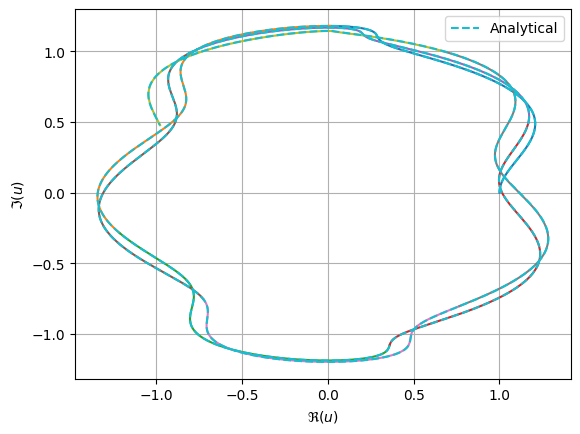

In [ ]:
tt = np.linspace(t0, tEnd, 10)
occ = 0
p = pStart
uStart = u0
for i in range(1,len(tt)):
    tNum1, uNum1, TPNum1, UPNum1, occNum1, NNum1 = timeStepperDahlquist(uStart, tt[i-1], tt[i], 0.0001, p, occ)
    occ = occNum1
    p = NNum1
    uStart = uNum1[-1]
    plt.plot(uNum1.real, uNum1.imag)
    print(f"Step {i}\n Period point captured: {TPNum1},\n UP: {UPNum1}")
plt.plot(uTh.real, uTh.imag, "--", label="Analytical")
plt.legend(), plt.xlabel(r"$\Re(u)$"), plt.ylabel(r"$\Im(u)$"), plt.grid();

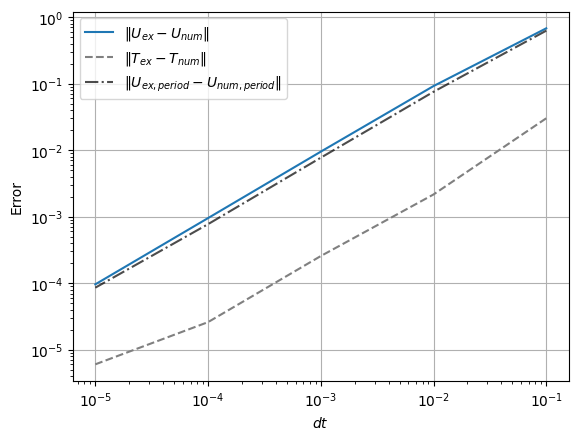

In [8]:
# compute errors for different time step sizes

dtVals =  1./(10**np.arange(1,6))
errors_sol = np.zeros_like(dtVals)
errors_TP = np.zeros_like(dtVals)
errors_UP = np.zeros_like(dtVals)
for i, dt in enumerate(dtVals):
    tTh, uTh,tpTh,upTh = analyticalDahlquist(u0, t0, tEnd, dt,pStart)
    tNum, uNum,tpNum,upNum, occNum, NNum = timeStepperDahlquist(u0, t0, tEnd, dt, pStart)
    min_len = min(len(uTh), len(uNum))
    uNum = uNum[:min_len]
    uTh = uTh[:min_len]
    errors_sol[i] = np.linalg.norm(uNum-uTh, ord=np.inf)
    tp_Th = np.asarray(tpTh)
    tp_Num = np.asarray(tpNum)
    errors_TP[i] = np.linalg.norm(tp_Num-tp_Th, ord=np.inf)  
    up_Th = np.asarray(upTh)
    up_Num = np.asarray(upNum)
    errors_UP[i] = np.linalg.norm(up_Num-up_Th, ord=np.inf)
plt.loglog(dtVals, errors_sol, label=r"$\|U_{ex} - U_{num}\|$")
plt.loglog(dtVals, errors_TP, "--", c="gray", label=r"$\|T_{ex} - T_{num}\|$")
plt.loglog(dtVals, errors_UP, "-.", c="black", label=r"$\|U_{ex,period} - U_{num, period}\|$", alpha=0.7)
plt.xlabel("$dt$"), plt.ylabel("Error"), plt.grid();
plt.legend()
plt.show()

In [9]:
# Parareal with fixed window grid 
# adaptive time in period points and solution in the fixed time grid
# Parareal setup
N = 5
NP = 4
K = 7
dtF = 1/1000
dtG = 1/10


TT =  np.linspace(t0, tEnd, N+1)
TT_p = np.zeros((K+1, N), dtype=float)
U_p = np.zeros((K+1, N), dtype=complex)
U = np.zeros((K+1, N+1), dtype=complex)
U[:, 0] = u0

# Fine and coarse solvers
F = lambda u0, t0, t1, p, occ: timeStepperDahlquist(u0, t0, t1, dtF, p, occ)[1:] # fine solver
G = lambda u0, t0, t1, p, occ: timeStepperDahlquist(u0, t0, t1, dtG, p, occ)[1:] # coarse solver

# Initial guess
p = pStart
occ = 0
for n in range(N):
    uG, tpG, upG, occG, pG = G(U[0, n], TT[n], TT[n+1], p, occ)
    U[0, n+1] = uG[-1]
    p = pG
    occ = occG
    TT_p[0, n] = tpG[0] if len(tpG) > 0 else 0
    U_p[0, n] = upG[0] if len(upG) > 0 else 0
    #plt.plot(uG.real, uG.imag, label=f"Coarse solver n={n}")



for k in range(K):
    pF_old = pStart
    pG_old = pStart
    p_seq_old = pStart
    occ = 0
    for n in range(N):
        uF, tpF, upF, occF, pF = F(U[k, n], TT[n], TT[n+1], pF_old, occ)
        uG, tpG, upG, occG, pG = G(U[k, n], TT[n], TT[n+1], pG_old, occ)
        uG_seq, tpG_seq, upG_seq, occG_seq, pG_seq = G(U[k+1, n], TT[n], TT[n+1], p_seq_old, occ)
        U[k+1, n+1] = uF[-1] - uG[-1] + uG_seq[-1]
        TPF = tpF[0] if len(tpF) > 0 else 0
        TPG = tpG[0] if len(tpG) > 0 else 0
        TPG_seq = tpG_seq[0] if len(tpG_seq) > 0 else 0

        TT_p[k+1, n] = TPF - TPG + TPG_seq
        UPF = upF[0] if len(upF) > 0 else 0
        UPG = upG[0] if len(upG) > 0 else 0
        UPG_seq = upG_seq[0] if len(upG_seq) > 0 else 0
        U_p[k+1, n] = UPF - UPG + UPG_seq
        
        # also sequantially updated values for the next iteration
        pF_old = pF
        pG_old = pG
        p_seq_old = pG_seq
        occ = occF



In [10]:
# compute the numerical solution for error analysis
dtF_index = np.where(dtVals == dtF)[0][0]
thres_U = errors_sol[dtF_index]
thres_TP = errors_TP[dtF_index]
thres_UP = errors_UP[dtF_index]

UNum = [u0]
p = pStart
occ=0
tpNum = []
upNum = []
for i in range(1,len(TT)):
    _, U1, tp1, uP1, occ1, N1 = timeStepperDahlquist(UNum[-1], TT[i-1], TT[i], dtF, p, occ)
    occ = occ1
    p = N1
    UNum.append(U1[-1])

    if len(tp1) > 0:
        tpNum.append(tp1[0])
        upNum.append(uP1[0])
#    plt.plot(U1.real, U1.imag, label=f"Exact solution on window {i}")

#tTh, uTh, TPTh, UPTh = analyticalDahlquist(u0, TT[0], TT[-1], dtF, 1)

#plt.plot(uTh.real, uTh.imag, "--", label="Analytical")
#plt.legend()
#plt.xlabel("Real part")
#plt.ylabel("Imaginary part")
#plt.title("Solutions in the complex plane")

#for k in range(K+1):    
#    err.append(np.linalg.norm(coarse_U_exact - U[k, :], ord=np.inf))


In [11]:
bla = TT_p[0,:]!=0
thres_U

np.float64(0.009491269998757101)

In [12]:
# compute the exact solution for error analysis
error_TP_points = np.zeros((K+1, len(tpNum)), dtype=float)
error_TP = np.zeros((K+1), dtype=float)
error_UP_points = np.zeros((K+1, len(upNum)), dtype=float)
error_UP = np.zeros((K+1), dtype=float)


error_U_points = np.zeros((K+1,N+1), dtype=float)
error_U = np.zeros((K+1), dtype=float)
for k in range(K+1):    
    error_U_points[k, :] = np.abs(UNum - U[k, :])
    error_U[k] = np.linalg.norm(error_U_points[k, :], ord=np.inf)
    
    non_zero_indices = TT_p[k, :] != 0
    error_TP_points[k, :] = np.abs(tpNum - TT_p[k, non_zero_indices])
    error_TP[k] = np.linalg.norm(error_TP_points[k, :], ord=np.inf)

    error_UP_points[k, :] = np.abs(upNum - U_p[k, non_zero_indices])
    error_UP[k] = np.linalg.norm(error_UP_points[k, :], ord=np.inf)


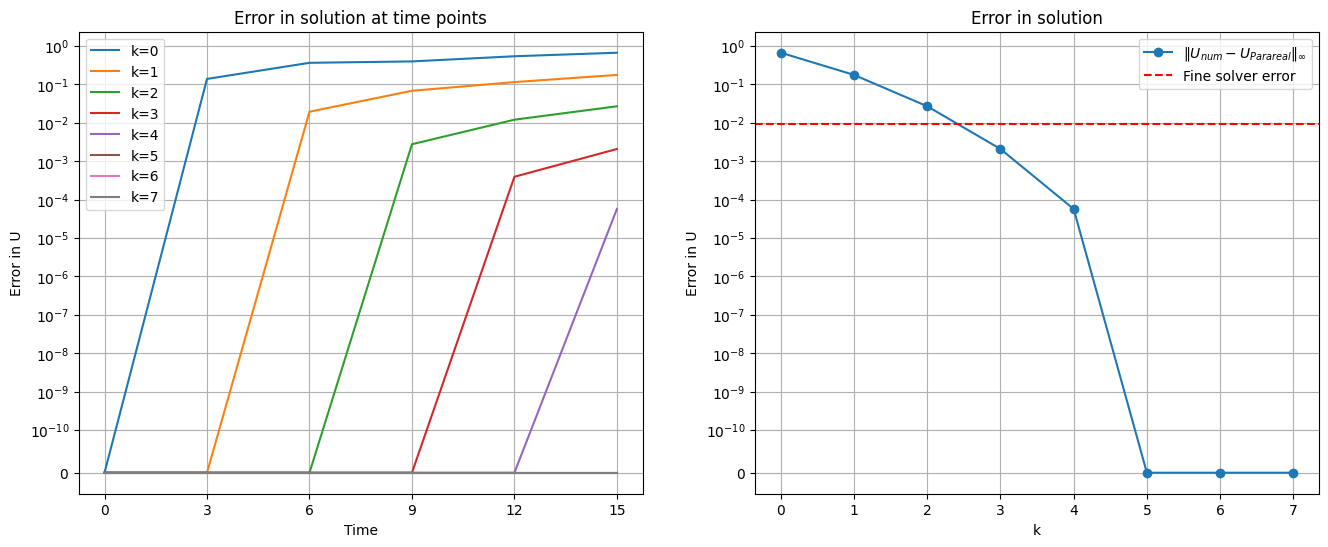

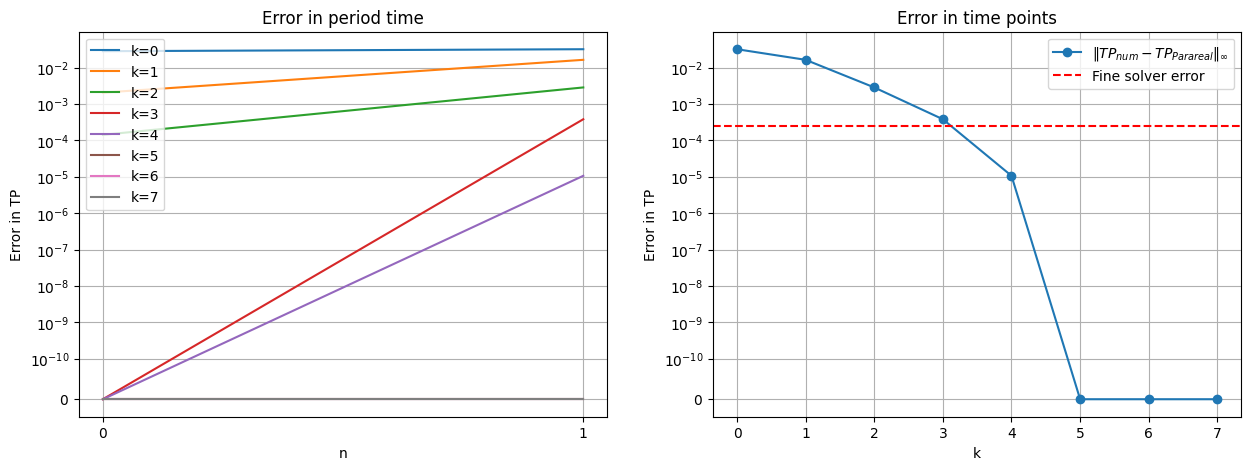

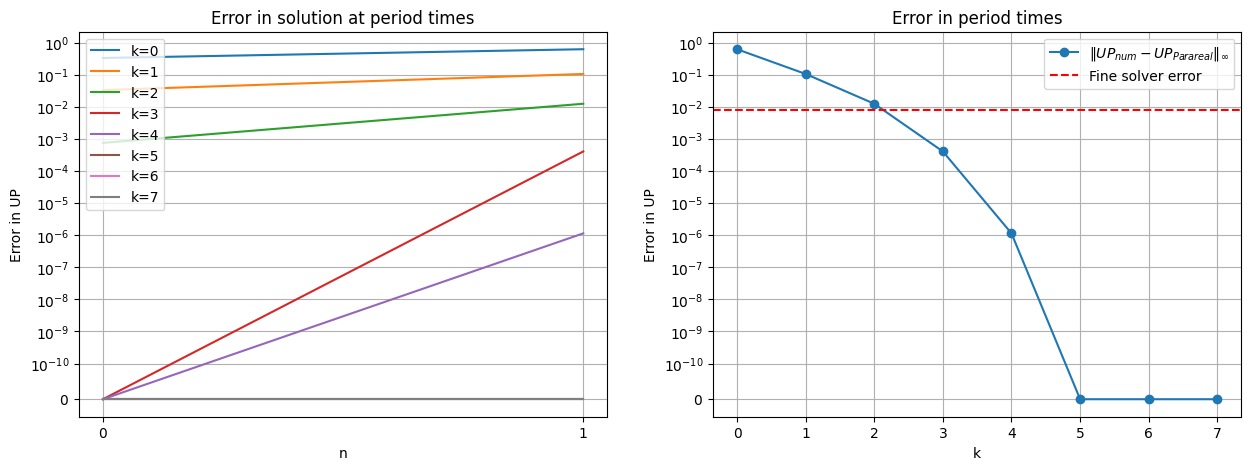

In [13]:
# plot the errors

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
for k in range(K+1):    
    plt.semilogy(TT, error_U_points[k, :], label=f"k={k}")
plt.xticks(TT)
plt.xlabel("Time"), plt.ylabel("Error in U"), plt.title("Error in solution at time points"), plt.grid(), plt.legend(loc="upper left")
plt.yscale('symlog', linthresh=1e-10)

plt.subplot(1, 2, 2)
plt.semilogy(range(K+1), error_U, "o-", label=r"$\|U_{num} - U_{Parareal}\|_\infty$")
plt.axhline(y=thres_U, color='red', linestyle='--', label="Fine solver error")
plt.xlabel("k"), plt.ylabel("Error in U"), plt.title("Error in solution"), plt.grid(), plt.legend(loc="upper right")
plt.yscale('symlog', linthresh=1e-10)

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
x = np.arange(len(tpNum))
for k in range(K+1):
    plt.semilogy(x, error_TP_points[k, :], label=f"k={k}")
plt.xticks(x)
plt.xlabel("n"), plt.ylabel("Error in TP"), plt.title("Error in period time"), plt.grid(), plt.legend(loc="upper left")
plt.yscale('symlog', linthresh=1e-10)


plt.subplot(1, 2, 2)
plt.semilogy(range(K+1), error_TP, "o-", label=r"$\|TP_{num} - TP_{Parareal}\|_\infty$")
plt.axhline(y=thres_TP, color='red', linestyle='--', label="Fine solver error")
plt.xlabel("k"), plt.ylabel("Error in TP"), plt.title("Error in time points"), plt.grid(), plt.legend(loc="upper right")
plt.yscale('symlog', linthresh=1e-10)

plt.figure(figsize=(15, 5))

plt.subplot(1,2,1)
for k in range(K+1):    
    plt.semilogy(x, error_UP_points[k, :], label=f"k={k}")
plt.xticks(x)
plt.xlabel("n"), plt.ylabel("Error in UP"), plt.title("Error in solution at period times"), plt.grid(), plt.legend(loc="upper left")
plt.yscale('symlog', linthresh=1e-10)


plt.subplot(1, 2, 2)
plt.semilogy(range(K+1), error_UP, "o-", label=r"$\|UP_{num} - UP_{Parareal}\|_\infty$")
plt.axhline(y=thres_UP, color='red', linestyle='--', label="Fine solver error")
plt.xlabel("k"), plt.ylabel("Error in UP"), plt.title("Error in period times"), plt.grid(), plt.legend(loc="upper right")
plt.yscale('symlog', linthresh=1e-10)